# The Derivative Rules, Verified

**This notebook is self-contained; it recaps the difference quotient before using it.**

Computing a limit from scratch every time you need a derivative would be unbearable. Fortunately a
handful of **rules** cover almost everything, and once you know them differentiation becomes
mechanical. This notebook lists them and then — rather than asking you to take them on faith —
**checks every one numerically** against the definition.

## Learning objectives

- State the power, constant-multiple, sum, product, quotient, and chain rules.
- Recall the derivatives of $\sin x$, $\cos x$, and $e^x$.
- **Verify** a rule by comparing it against the difference quotient.

## Background

Recall the definition from the previous notebook: the derivative is the limit of the difference
quotient,

$$f'(x) = \lim_{h\to 0}\frac{f(x+h) - f(x)}{h}$$

Every rule below is a shortcut that was *derived* from that definition once, so nobody has to redo the
limit. The essential ones:

| Rule | Statement |
|---|---|
| Power | $\dfrac{d}{dx}x^n = n x^{n-1}$ |
| Constant multiple | $(c f)' = c f'$ |
| Sum | $(f + g)' = f' + g'$ |
| Product | $(fg)' = f'g + fg'$ |
| Quotient | $\left(\dfrac{f}{g}\right)' = \dfrac{f'g - fg'}{g^2}$ |
| Chain | $\dfrac{d}{dx}f(g(x)) = f'(g(x))\, g'(x)$ |

And the common functions: $\dfrac{d}{dx}\sin x = \cos x$, $\dfrac{d}{dx}\cos x = -\sin x$,
$\dfrac{d}{dx}e^x = e^x$.

The two that trip people up are the product and quotient rules — the derivative of a product is
**not** the product of the derivatives. We check that explicitly below.

## This notebook covers

1. How we will check a rule.
2. The power rule and the easy rules.
3. Product and quotient — and why the "obvious" guess is wrong.
4. The chain rule.
5. A summary table of every rule, checked at once.

**Prerequisites:** `U3-3_Derivatives-1_SecantToTangent`

**Dataset:** none — functions are entered directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Check a rule against the DEFINITION: the difference quotient with a small h.
# (This is the forward difference from the previous notebook. There are more accurate
#  ways to do this numerically -- that is what section 3.4 is about -- but the point
#  here is to compare against the definition itself, not against a better method.)
def numerical_derivative(f, x, h=1e-6):
    return (f(x + h) - f(x)) / h


def check_rule(name, f, claimed_derivative, x=1.3):
    exact = claimed_derivative(x)
    approx = numerical_derivative(f, x)
    print(f"{name:<26} rule says {exact:12.6f}   definition gives {approx:12.6f}   "
          f"|diff| {abs(exact - approx):.2e}")

## 1. How we check

For each rule we do the same thing: apply the rule to get a formula for $f'$, then compare that
formula against the **difference quotient** with a small $h$. If the rule is right, the two agree to
several decimal places.

They will not agree *exactly*, and that is expected — the difference quotient with $h = 10^{-6}$ is an
approximation, not the limit itself. A `|diff|` around $10^{-6}$ or smaller means the rule checks out.
(Quantifying that error properly is §3.4's job.)

## 2. The power rule and friends

$$\frac{d}{dx}x^n = n x^{n-1}$$

Multiply by the old exponent, then knock it down by one. It works for any $n$ — negative, fractional,
whatever — as the checks below show. The constant-multiple and sum rules then let you differentiate
any polynomial term by term.

In [2]:
check_rule("x^2",            lambda x: x**2,        lambda x: 2*x)
check_rule("x^5",            lambda x: x**5,        lambda x: 5*x**4)
check_rule("x^(-2)",         lambda x: x**-2,       lambda x: -2*x**-3)
check_rule("sqrt(x) = x^0.5", lambda x: x**0.5,     lambda x: 0.5*x**-0.5)
print()
check_rule("7 x^3 (constant)", lambda x: 7*x**3,    lambda x: 21*x**2)
check_rule("x^3 + x^2 (sum)",  lambda x: x**3 + x**2, lambda x: 3*x**2 + 2*x)
print()
check_rule("sin(x)",         np.sin,                np.cos)
check_rule("cos(x)",         np.cos,                lambda x: -np.sin(x))
check_rule("exp(x)",         np.exp,                np.exp)

x^2                        rule says     2.600000   definition gives     2.600001   |diff| 1.00e-06
x^5                        rule says    14.280500   definition gives    14.280522   |diff| 2.20e-05
x^(-2)                     rule says    -0.910332   definition gives    -0.910331   |diff| 1.05e-06
sqrt(x) = x^0.5            rule says     0.438529   definition gives     0.438529   |diff| 8.45e-08

7 x^3 (constant)           rule says    35.490000   definition gives    35.490027   |diff| 2.73e-05
x^3 + x^2 (sum)            rule says     7.670000   definition gives     7.670005   |diff| 4.90e-06

sin(x)                     rule says     0.267499   definition gives     0.267498   |diff| 4.82e-07
cos(x)                     rule says    -0.963558   definition gives    -0.963558   |diff| 1.34e-07
exp(x)                     rule says     3.669297   definition gives     3.669299   |diff| 1.83e-06


## 3. Products and quotients

Here is the rule people most want to be simpler than it is:

$$(fg)' = f'g + fg'$$

The derivative of a product is **not** $f'g'$. It is worth seeing that fail numerically once, so the
correct rule sticks.

For $f = x^2$ and $g = \sin x$: the naive guess gives $2x\cos x$, while the real product rule gives
$2x\sin x + x^2\cos x$. Only one of them matches the definition.

In [3]:
f = lambda x: x**2
g = np.sin
product = lambda x: f(x) * g(x)

x0 = 1.3
naive = (2*x0) * np.cos(x0)                          # WRONG: f' times g'
correct = 2*x0*np.sin(x0) + x0**2*np.cos(x0)         # product rule
definition = numerical_derivative(product, x0)

print(f"at x = {x0}, for f(x) = x^2 times g(x) = sin(x):\n")
print(f"  naive guess  f' g'      = {naive:12.6f}    <- WRONG")
print(f"  product rule f'g + fg'  = {correct:12.6f}")
print(f"  the definition          = {definition:12.6f}    <- the product rule matches")

at x = 1.3, for f(x) = x^2 times g(x) = sin(x):

  naive guess  f' g'      =     0.695497    <- WRONG
  product rule f'g + fg'  =     2.957324
  the definition          =     2.957325    <- the product rule matches


In [4]:
check_rule("x^2 sin(x)  (product)", lambda x: x**2 * np.sin(x),
           lambda x: 2*x*np.sin(x) + x**2*np.cos(x))
check_rule("x exp(x)    (product)", lambda x: x * np.exp(x),
           lambda x: np.exp(x) + x*np.exp(x))
print()
check_rule("sin(x)/x    (quotient)", lambda x: np.sin(x)/x,
           lambda x: (np.cos(x)*x - np.sin(x)) / x**2)
check_rule("x^2/(x+1)   (quotient)", lambda x: x**2/(x+1),
           lambda x: (2*x*(x+1) - x**2) / (x+1)**2)

x^2 sin(x)  (product)      rule says     2.957324   definition gives     2.957325   |diff| 8.45e-07
x exp(x)    (product)      rule says     8.439382   definition gives     8.439388   |diff| 6.05e-06

sin(x)/x    (quotient)     rule says    -0.364384   definition gives    -0.364385   |diff| 9.03e-08
x^2/(x+1)   (quotient)     rule says     0.810964   definition gives     0.810964   |diff| 8.21e-08


## 4. The chain rule

$$\frac{d}{dx}f(g(x)) = f'(g(x))\cdot g'(x)$$

For a function inside a function: differentiate the outer one (leaving the inside alone), then
multiply by the derivative of the inside. The "multiply by the inside's derivative" step is the part
that gets forgotten.

This is the rule that matters most downstream — it is what makes **backpropagation** work when
training a neural network, since a network is a long chain of nested functions.

In [5]:
check_rule("sin(x^2)",      lambda x: np.sin(x**2),
           lambda x: np.cos(x**2) * 2*x)
check_rule("(3x + 1)^4",    lambda x: (3*x + 1)**4,
           lambda x: 4*(3*x + 1)**3 * 3)
check_rule("exp(sin(x))",   lambda x: np.exp(np.sin(x)),
           lambda x: np.exp(np.sin(x)) * np.cos(x))
print()
# forgetting the inner derivative is the classic mistake
x0 = 1.3
print(f"sin(x^2) at x = {x0}:")
print(f"  forgetting the inner derivative: {np.cos(x0**2):12.6f}   <- WRONG")
print(f"  chain rule, cos(x^2) * 2x      : {np.cos(x0**2)*2*x0:12.6f}")
print(f"  the definition                 : {numerical_derivative(lambda x: np.sin(x**2), x0):12.6f}")

sin(x^2)                   rule says    -0.309196   definition gives    -0.309200   |diff| 3.47e-06
(3x + 1)^4                 rule says  1411.788000   definition gives  1411.789296   |diff| 1.30e-03
exp(sin(x))                rule says     0.701116   definition gives     0.701115   |diff| 1.17e-06

sin(x^2) at x = 1.3:
  forgetting the inner derivative:    -0.118922   <- WRONG
  chain rule, cos(x^2) * 2x      :    -0.309196
  the definition                 :    -0.309200


## 5. Seeing a rule work across the whole domain

Checking at one point is suggestive; checking everywhere is convincing. Below, the rule's formula and
the difference quotient are plotted together over an interval — they lie on top of each other.

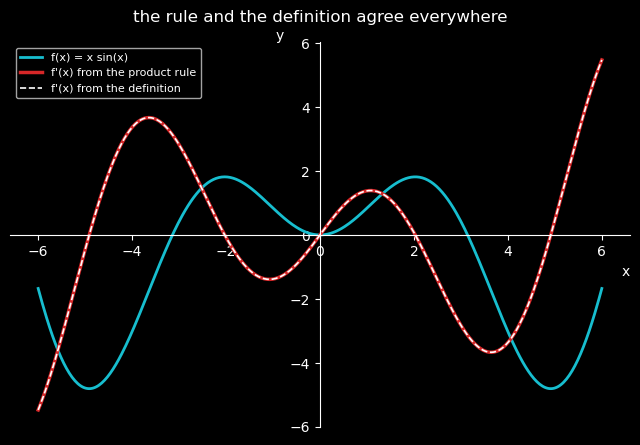

largest disagreement anywhere on the interval: 2.77e-06


In [6]:
func = lambda x: x * np.sin(x)                       # a product
rule = lambda x: np.sin(x) + x * np.cos(x)           # product rule

xs = np.linspace(-6, 6, 400)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, func(xs), color="tab:cyan", lw=2, label="f(x) = x sin(x)")
ax.plot(xs, rule(xs), color="tab:red", lw=2.5, label="f'(x) from the product rule")
ax.plot(xs, numerical_derivative(func, xs), "--", color="white", lw=1.2,
        label="f'(x) from the definition")

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.legend(loc="upper left", fontsize=8)
ax.set_title("the rule and the definition agree everywhere", pad=15)
plt.show()

worst = np.max(np.abs(rule(xs) - numerical_derivative(func, xs)))
print(f"largest disagreement anywhere on the interval: {worst:.2e}")

## 6. Summary

- The **rules** replace computing a limit every time. Power, constant multiple, and sum handle
  polynomials; product, quotient, and chain handle everything built from combinations.
- $\dfrac{d}{dx}\sin x = \cos x$, $\dfrac{d}{dx}\cos x = -\sin x$, $\dfrac{d}{dx}e^x = e^x$.
- **The derivative of a product is not the product of the derivatives** — it is $f'g + fg'$.
- The **chain rule** needs that final multiplication by the inner derivative; forgetting it is the
  classic error. It is also the engine of backpropagation.
- Every rule here was checked against the difference quotient, agreeing to about $10^{-6}$ — the
  accuracy of the numerical check, not of the rule.

Next: what the *second* derivative tells you, and the shape it describes
(`U3-3_Derivatives-3_SecondDerivativeAndConcavity`).